# 📊 Notebook 03: Exploratory Data Analysis (EDA) on Pure Human Gold Standard Dataset

**Proyek:** Aspect-Based Sentiment Analysis (ABSA) Komentar YouTube EV China di Indonesia  
**Tujuan Notebook:** 
Melakukan analisis eksploratif mendalam terhadap dataset terlabel **100% Murni Audit Manusia (Pure Human Gold Standard)** (`data/interim/master_labeled_comments.csv`, `data/interim/valid_labeled_comments.csv`, dan split data `train.csv` (70%) & `val.csv` (30%) di `data/processed/`).

### 🎯 Pokok Bahasan Analisis:
1. **Rasio Komentar Ber-Aspek vs Non-Aspek** (Total 3.016 Komentar).
2. **Distribusi Sentimen per Aspek** (`Infrastruktur`, `Ekonomi`, `Kualitas`, `Purnajual`).
3. **Perbandingan Keseluruhan Sentimen (Positif, Netral, Negatif dari Seluruh Aspek Gabungan).**
4. **Analisis Komentar Multi-Aspek** (Ko-eksistensi & Overlap antar aspek).
5. **Distribusi Panjang Teks** (Karakter & Jumlah Kata per Aspek & Sentimen).
6. **Visualisasi Kata Dominan (WordClouds)** untuk Setiap Aspek (dengan Filtering Stopwords).
7. **Verifikasi Keseimbangan Stratified Dataset Split** (Train 70% & Val 30%).


In [1]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from wordcloud import WordCloud
from collections import Counter
import warnings

warnings.filterwarnings('ignore')

# Style plot
plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams['font.sans-serif'] = 'DejaVu Sans'
plt.rcParams['figure.dpi'] = 120

print("Library visualisasi berhasil dimuat.")


Library visualisasi berhasil dimuat.


In [2]:
# Path Berkas
master_path = '../data/interim/master_labeled_comments.csv'
valid_path = '../data/interim/valid_labeled_comments.csv'
train_path = '../data/processed/train.csv'
val_path = '../data/processed/val.csv'

# Fallback ke path relatif lokal jika dijalankan dari root
if not os.path.exists(master_path):
    master_path = 'data/interim/master_labeled_comments.csv'
    valid_path = 'data/interim/valid_labeled_comments.csv'
    train_path = 'data/processed/train.csv'
    val_path = 'data/processed/val.csv'

df_master = pd.read_csv(master_path)
df_valid = pd.read_csv(valid_path)
df_train = pd.read_csv(train_path)
df_val = pd.read_csv(val_path)

print(f"Master Dataset Loaded  : {len(df_master)} komentar")
print(f"Valid Dataset Loaded   : {len(df_valid)} komentar (100% Pure Human Gold Standard)")
print(f"Train Dataset Loaded   : {len(df_train)} komentar (70%)")
print(f"Val Dataset Loaded     : {len(df_val)} komentar (30%)")


Master Dataset Loaded  : 3016 komentar
Valid Dataset Loaded   : 954 komentar (100% Pure Human Gold Standard)
Train Dataset Loaded   : 667 komentar (70%)
Val Dataset Loaded     : 287 komentar (30%)


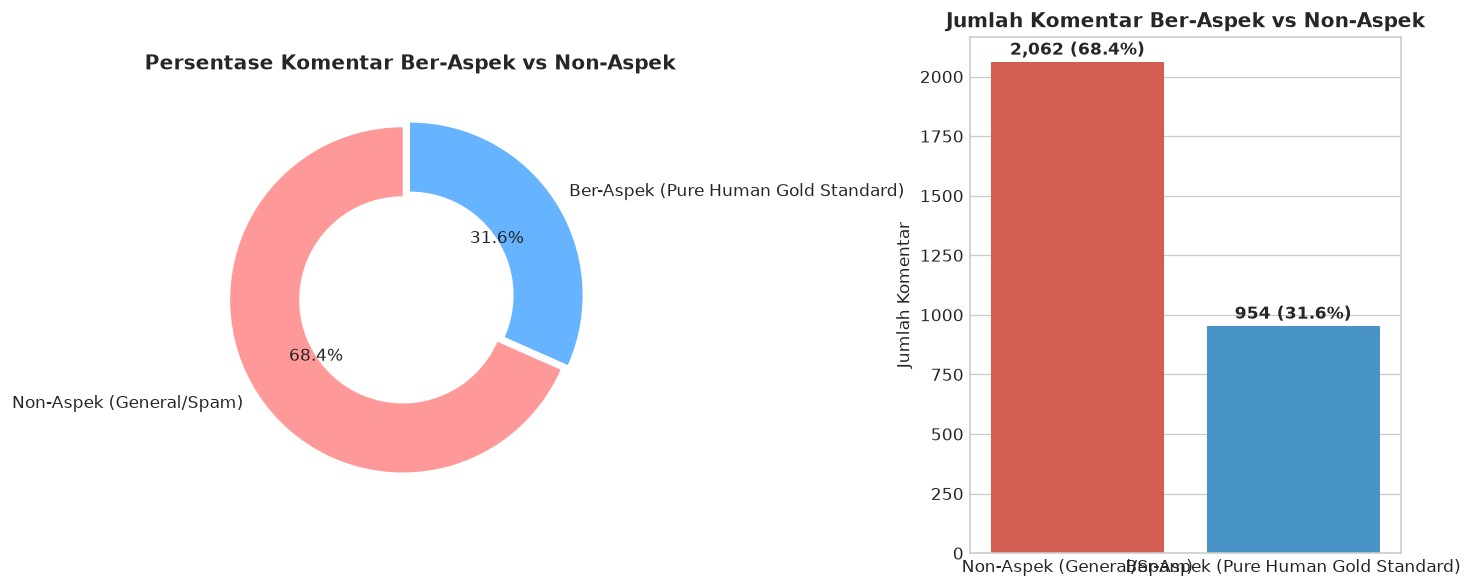

In [3]:
# 1. Rasio Komentar Ber-Aspek vs Non-Aspek
aspect_cols = ['infra_sentiment', 'ekonomi_sentiment', 'kualitas_sentiment', 'purnajual_sentiment']
df_master['is_aspect_bearing'] = df_master[aspect_cols].notnull().any(axis=1)

counts = df_master['is_aspect_bearing'].value_counts()
labels = ['Non-Aspek (General/Spam)', 'Ber-Aspek (Pure Human Gold Standard)']

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Donut Chart
colors = ['#ff9999','#66b3ff']
axes[0].pie(counts, labels=labels, autopct='%1.1f%%', startangle=90, colors=colors, explode=(0.05, 0), wedgeprops=dict(width=0.4))
axes[0].set_title('Persentase Komentar Ber-Aspek vs Non-Aspek', fontsize=12, fontweight='bold')

# Bar Chart
sns.barplot(x=labels, y=counts.values, palette=['#e74c3c', '#3498db'], ax=axes[1])
axes[1].set_title('Jumlah Komentar Ber-Aspek vs Non-Aspek', fontsize=12, fontweight='bold')
axes[1].set_ylabel('Jumlah Komentar')
for i, v in enumerate(counts.values):
    axes[1].text(i, v + 30, f"{v:,} ({v/len(df_master)*100:.1f}%)", ha='center', fontweight='bold')

plt.tight_layout()
plt.show()


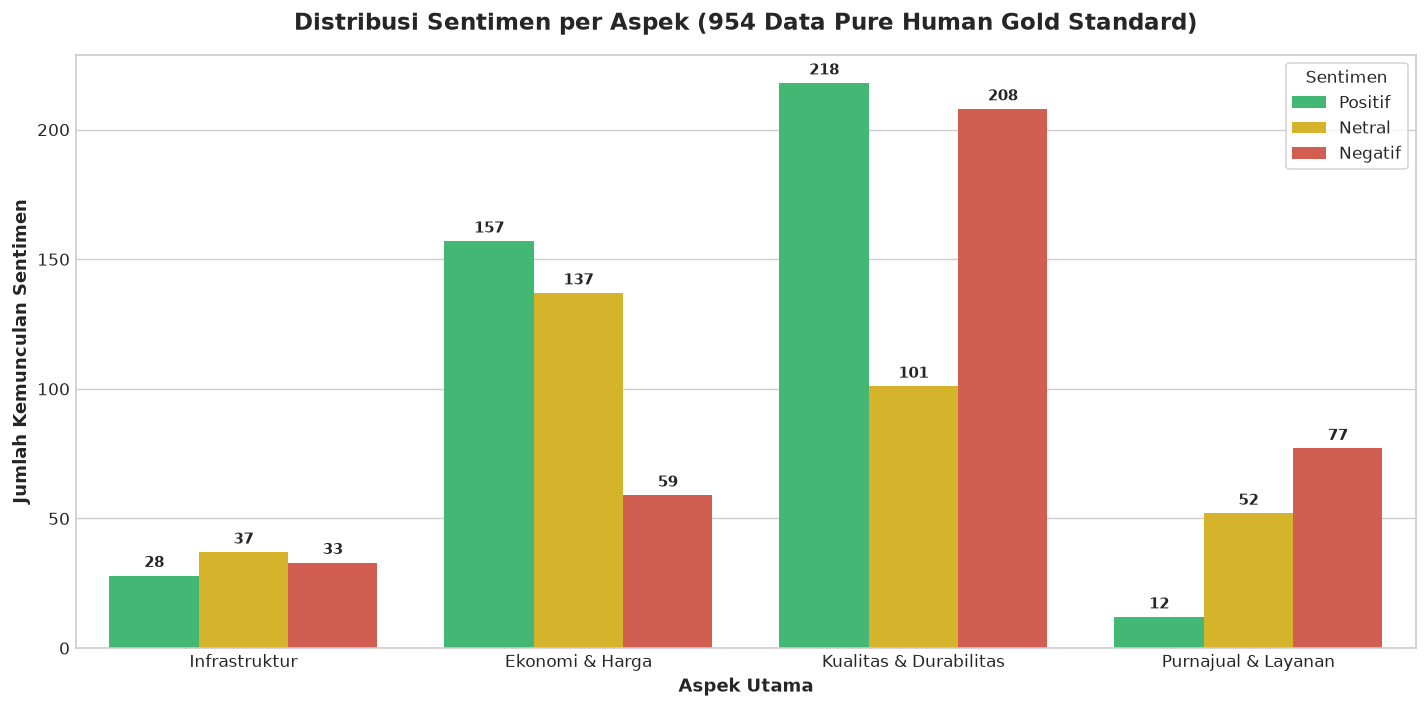

In [4]:
# 2. Distribusi Sentimen per Aspek
aspect_names = {
    'infra_sentiment': 'Infrastruktur',
    'ekonomi_sentiment': 'Ekonomi & Harga',
    'kualitas_sentiment': 'Kualitas & Durabilitas',
    'purnajual_sentiment': 'Purnajual & Layanan'
}

records = []
for col, name in aspect_names.items():
    s_counts = df_valid[col].value_counts()
    for sent in ['positif', 'netral', 'negatif']:
        records.append({
            'Aspek': name,
            'Sentimen': sent.capitalize(),
            'Jumlah': s_counts.get(sent, 0)
        })

df_aspect_sent = pd.DataFrame(records)

plt.figure(figsize=(12, 6))
palette = {'Positif': '#2ecc71', 'Netral': '#f1c40f', 'Negatif': '#e74c3c'}

ax = sns.barplot(data=df_aspect_sent, x='Aspek', y='Jumlah', hue='Sentimen', palette=palette)
plt.title(f'Distribusi Sentimen per Aspek ({len(df_valid)} Data Pure Human Gold Standard)', fontsize=14, fontweight='bold', pad=15)
plt.xlabel('Aspek Utama', fontsize=11, fontweight='bold')
plt.ylabel('Jumlah Kemunculan Sentimen', fontsize=11, fontweight='bold')
plt.legend(title='Sentimen', frameon=True)

# Annotate bars
for p in ax.patches:
    height = p.get_height()
    if height > 0:
        ax.annotate(f'{int(height)}',
                    (p.get_x() + p.get_width() / 2., height),
                    ha='center', va='bottom', fontsize=9, fontweight='bold',
                    xytext=(0, 3), textcoords='offset points')

plt.tight_layout()
plt.show()


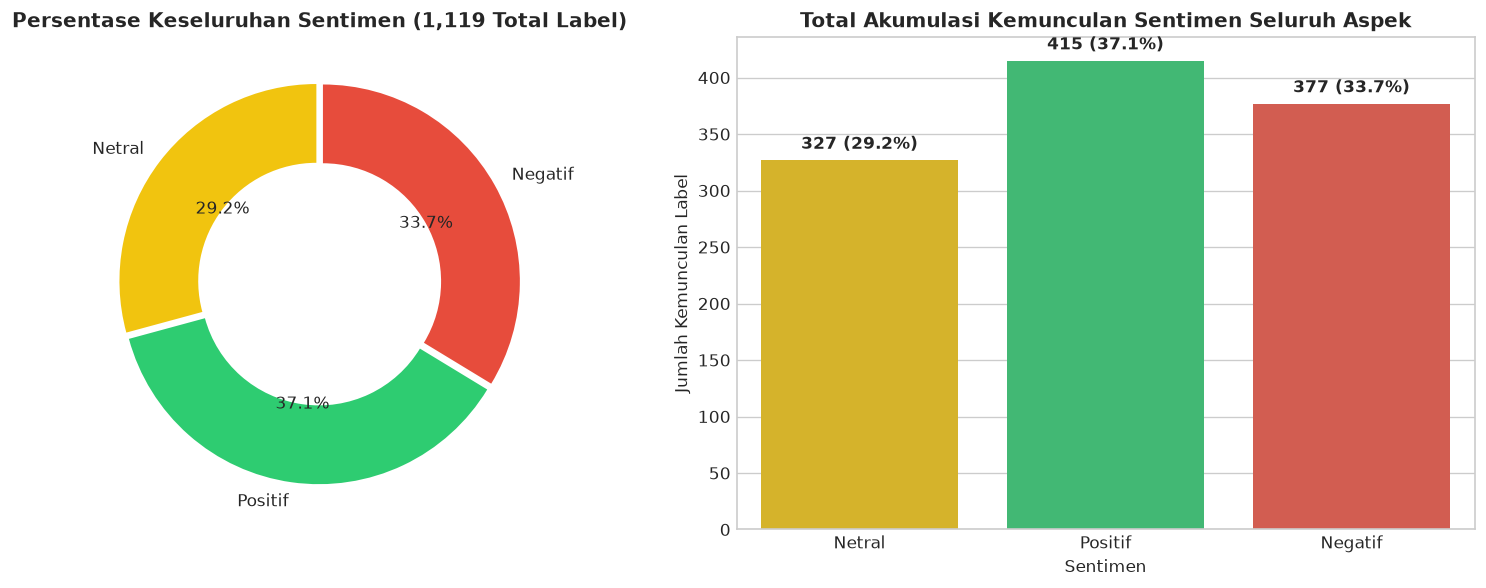

TOTAL AKUMULASI LABEL SENTIMEN MURNI AUDIT MANUSIA: 1,119 Anotasi Label
  - Netral  : 327 label (29.2%)
  - Positif : 415 label (37.1%)
  - Negatif : 377 label (33.7%)


In [5]:
# 2b. Perbandingan Keseluruhan Sentimen (Positif, Netral, Negatif dari Seluruh Aspek Gabungan)
total_positif = sum(df_valid[col].value_counts().get('positif', 0) for col in aspect_names.keys())
total_netral = sum(df_valid[col].value_counts().get('netral', 0) for col in aspect_names.keys())
total_negatif = sum(df_valid[col].value_counts().get('negatif', 0) for col in aspect_names.keys())

total_sentiments = total_positif + total_netral + total_negatif

df_overall_sent = pd.DataFrame({
    'Sentimen': ['Netral', 'Positif', 'Negatif'],
    'Jumlah': [total_netral, total_positif, total_negatif],
    'Persentase': [total_netral/total_sentiments*100, total_positif/total_sentiments*100, total_negatif/total_sentiments*100]
})

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Donut Chart Total Sentimen
colors = ['#f1c40f', '#2ecc71', '#e74c3c']
axes[0].pie(df_overall_sent['Jumlah'], labels=df_overall_sent['Sentimen'], autopct='%1.1f%%', 
            startangle=90, colors=colors, explode=(0.02, 0.02, 0.02), wedgeprops=dict(width=0.4))
axes[0].set_title(f'Persentase Keseluruhan Sentimen ({total_sentiments:,} Total Label)', fontsize=12, fontweight='bold')

# Bar Chart Total Sentimen
sns.barplot(data=df_overall_sent, x='Sentimen', y='Jumlah', palette=colors, ax=axes[1])
axes[1].set_title(f'Total Akumulasi Kemunculan Sentimen Seluruh Aspek', fontsize=12, fontweight='bold')
axes[1].set_ylabel('Jumlah Kemunculan Label')
for i, row in df_overall_sent.iterrows():
    axes[1].text(i, row['Jumlah'] + 10, f"{int(row['Jumlah']):,} ({row['Persentase']:.1f}%)", ha='center', fontweight='bold')

plt.tight_layout()
plt.show()

print(f"TOTAL AKUMULASI LABEL SENTIMEN MURNI AUDIT MANUSIA: {total_sentiments:,} Anotasi Label")
print(f"  - Netral  : {total_netral:,} label ({total_netral/total_sentiments*100:.1f}%)")
print(f"  - Positif : {total_positif:,} label ({total_positif/total_sentiments*100:.1f}%)")
print(f"  - Negatif : {total_negatif:,} label ({total_negatif/total_sentiments*100:.1f}%)")


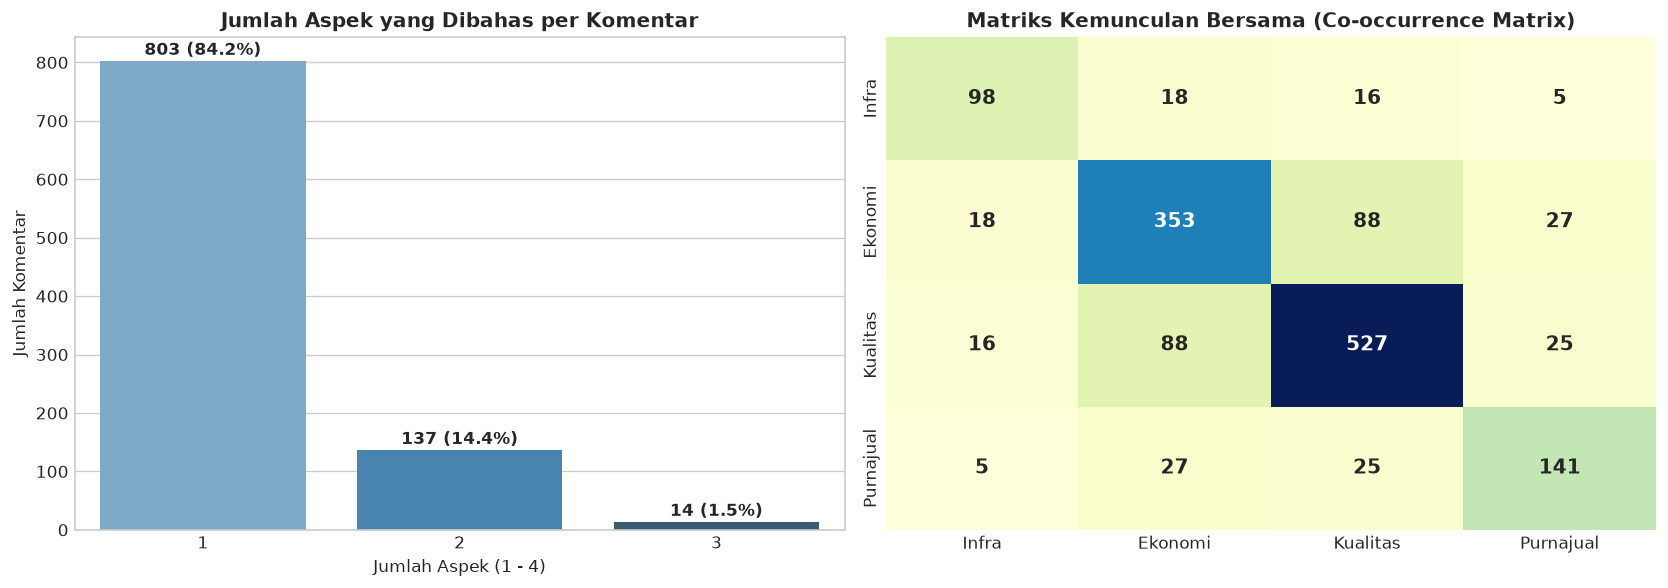

In [6]:
# 3. Analisis Multi-Aspek (Jumlah Aspek per Komentar & Co-occurrence)
df_valid['num_aspects'] = df_valid[aspect_cols].notnull().sum(axis=1)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Graph A: Jumlah Aspek per Komentar
num_asp_counts = df_valid['num_aspects'].value_counts().sort_index()
sns.barplot(x=num_asp_counts.index, y=num_asp_counts.values, palette='Blues_d', ax=axes[0])
axes[0].set_title('Jumlah Aspek yang Dibahas per Komentar', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Jumlah Aspek (1 - 4)')
axes[0].set_ylabel('Jumlah Komentar')
for i, v in enumerate(num_asp_counts.values):
    axes[0].text(i, v + 10, f"{v} ({v/len(df_valid)*100:.1f}%)", ha='center', fontweight='bold')

# Graph B: Co-occurrence Matrix (Overlap antar Aspek)
aspect_matrix = df_valid[aspect_cols].notnull().astype(int)
aspect_matrix.columns = ['Infra', 'Ekonomi', 'Kualitas', 'Purnajual']
co_matrix = aspect_matrix.T.dot(aspect_matrix)

sns.heatmap(co_matrix, annot=True, fmt='d', cmap='YlGnBu', cbar=False, ax=axes[1], annot_kws={'size': 12, 'weight': 'bold'})
axes[1].set_title('Matriks Kemunculan Bersama (Co-occurrence Matrix)', fontsize=12, fontweight='bold')

plt.tight_layout()
plt.show()


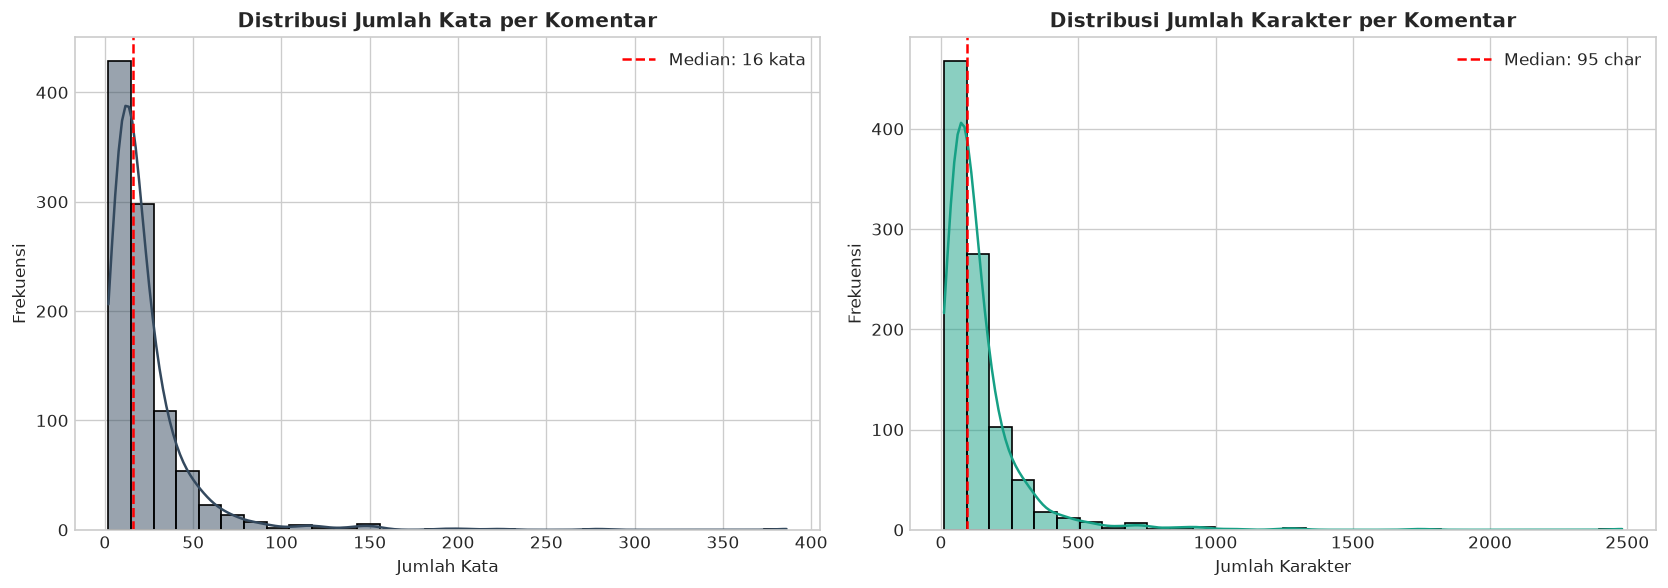

Statistik Panjang Kata    : Mean = 23.0 | Median = 16 | Max = 386
Statistik Panjang Karakter: Mean = 140.1 | Median = 95 | Max = 2481


In [7]:
# 4. Distribusi Panjang Teks (Kata & Karakter)
df_valid['char_length'] = df_valid['text_cleaned'].astype(str).apply(len)
df_valid['word_count'] = df_valid['text_cleaned'].astype(str).apply(lambda x: len(x.split()))

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Plot Kata
sns.histplot(df_valid['word_count'], kde=True, color='#34495e', ax=axes[0], bins=30)
axes[0].set_title('Distribusi Jumlah Kata per Komentar', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Jumlah Kata')
axes[0].set_ylabel('Frekuensi')
axes[0].axvline(df_valid['word_count'].median(), color='red', linestyle='--', label=f"Median: {df_valid['word_count'].median():.0f} kata")
axes[0].legend()

# Plot Karakter
sns.histplot(df_valid['char_length'], kde=True, color='#16a085', ax=axes[1], bins=30)
axes[1].set_title('Distribusi Jumlah Karakter per Komentar', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Jumlah Karakter')
axes[1].set_ylabel('Frekuensi')
axes[1].axvline(df_valid['char_length'].median(), color='red', linestyle='--', label=f"Median: {df_valid['char_length'].median():.0f} char")
axes[1].legend()

plt.tight_layout()
plt.show()

print(f"Statistik Panjang Kata    : Mean = {df_valid['word_count'].mean():.1f} | Median = {df_valid['word_count'].median():.0f} | Max = {df_valid['word_count'].max()}")
print(f"Statistik Panjang Karakter: Mean = {df_valid['char_length'].mean():.1f} | Median = {df_valid['char_length'].median():.0f} | Max = {df_valid['char_length'].max()}")


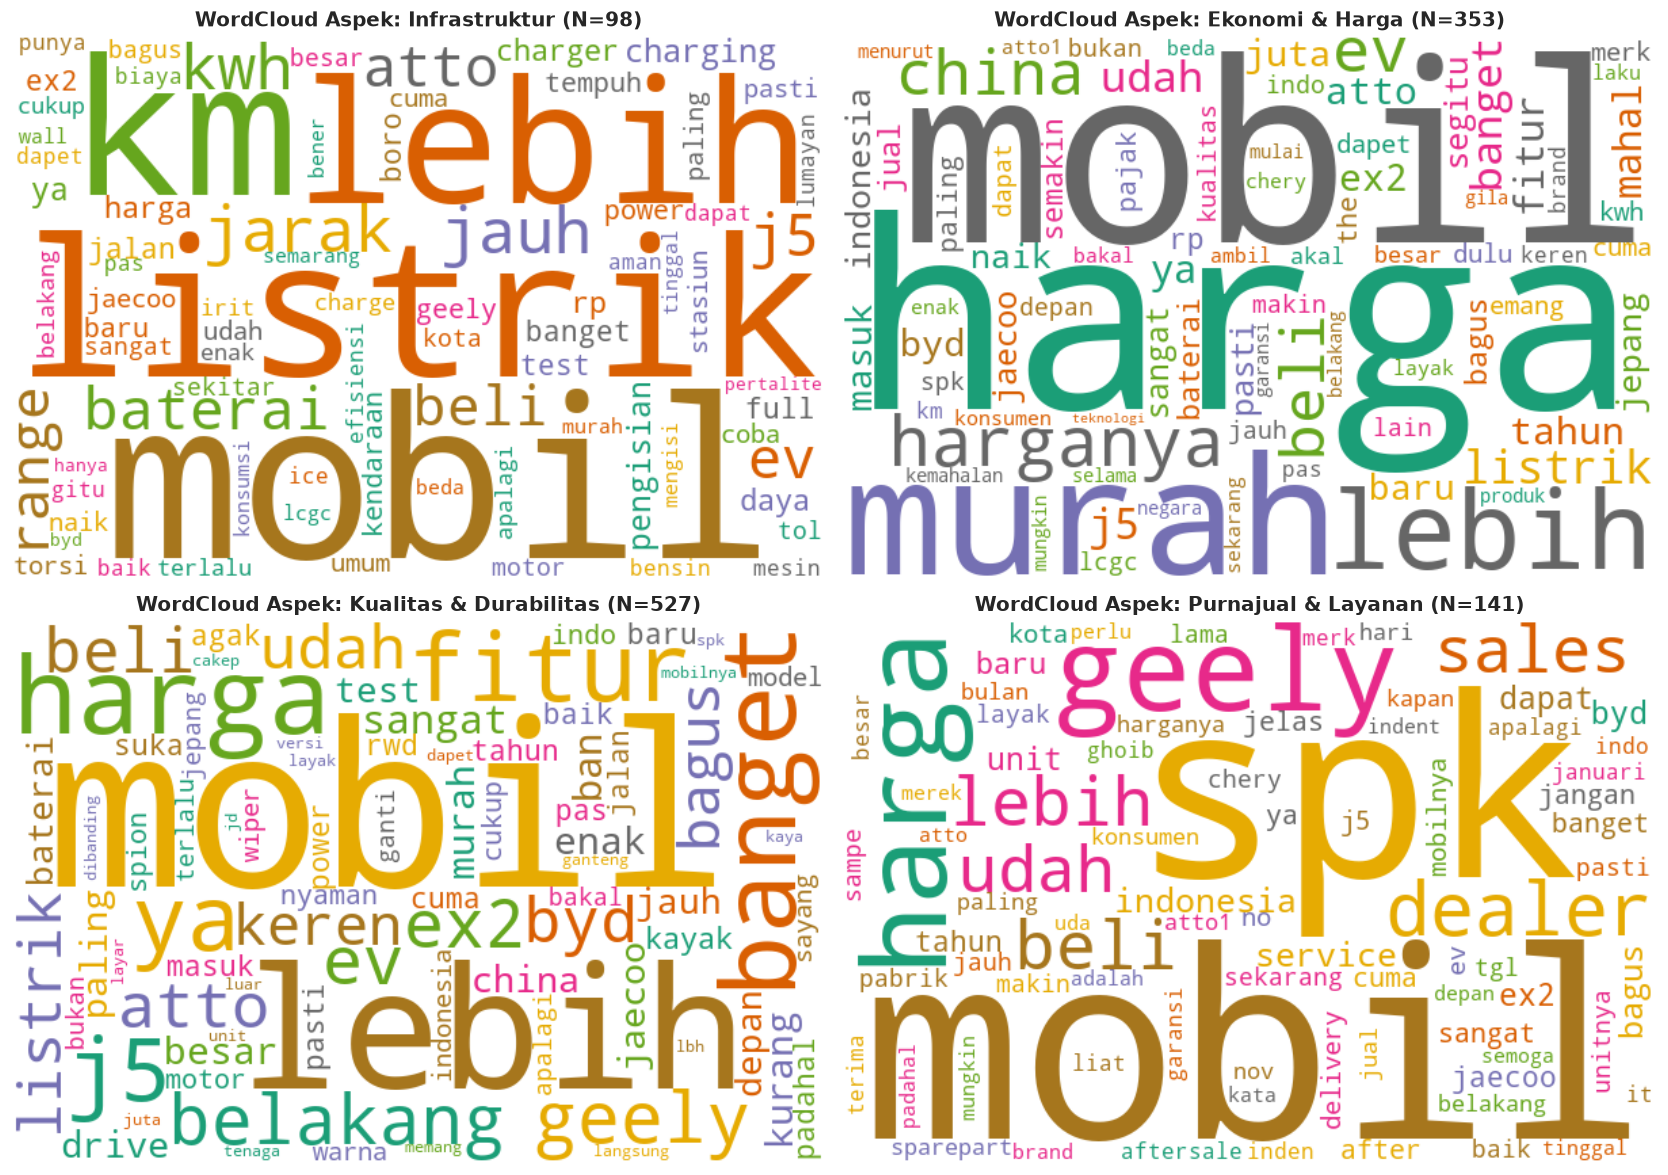

In [8]:
# 5. Visualisasi WordCloud Kata Kunci per Aspek (Filtered Stopwords untuk Visualisasi)
# Daftar Stopwords khusus visualisasi (TIDAK mengubah dataset asli)
VISUALIZATION_STOPWORDS = set([
    'yang', 'yg', 'nya', 'di', 'ke', 'dan', 'ini', 'itu', 'ada', 'sudah', 'bisa', 'banyak', 
    'lagi', 'sama', 'kalau', 'kalo', 'akan', 'jadi', 'bikin', 'dari', 'pada', 'buat', 'saja', 
    'aja', 'atau', 'dengan', 'untuk', 'lah', 'pun', 'kan', 'kah', 'deh', 'dong', 'kok', 'juga', 
    'masih', 'belum', 'harus', 'gak', 'ga', 'ngga', 'nggak', 'tidak', 'tak', 'gk', 'apa', 'tapi', 
    'tetap', 'biar', 'pakai', 'pake', 'mau', 'orang', 'sih', 'lu', 'gue', 'gw', 
    'gua', 'dia', 'mereka', 'kita', 'kamu', 'anda', 'saya', 'aku', 'sy', 'om', 'bang', 'min', 
    'bro', 'bos', 'gan', 'sist', 'kak', 'bapak', 'ibu', 'pak', 'bu', 'terus', 
    'seperti', 'karena', 'sampai', 'jika', 'bila', 'semua', 'hal', 'bahkan', 'secara', 'malah', 
    'sebab', 'oleh', 'serta', 'tersebut', 'tentang', 'bahwa', 'apabila', 'kalau'
])

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.flatten()

for idx, (col, name) in enumerate(aspect_names.items()):
    aspect_texts = df_valid[df_valid[col].notnull()]['text_cleaned'].astype(str)
    combined_text = " ".join(aspect_texts)
    
    wordcloud = WordCloud(
        width=600, height=400,
        background_color='white',
        colormap='Dark2',
        max_words=80,
        collocations=False,
        stopwords=VISUALIZATION_STOPWORDS
    ).generate(combined_text)
    
    axes[idx].imshow(wordcloud, interpolation='bilinear')
    axes[idx].set_title(f"WordCloud Aspek: {name} (N={len(aspect_texts)})", fontsize=12, fontweight='bold')
    axes[idx].axis('off')

plt.tight_layout()
plt.show()


Tabel Kemunculan Aspek pada Stratified Dataset Split (70/30):
      Split  Infrastruktur  Ekonomi & Harga  Kualitas & Durabilitas  Purnajual & Layanan
Train (667)             68              247                     367                  100
  Val (287)             30              106                     160                   41

Detail Distribusi Sentimen per Split (Train 70% vs Val 30%):

[Aspek Infrastruktur]
                 Train (70%)  Val (30%)
infra_sentiment                        
NaN                      599        257
netral                    25         12
negatif                   23         10
positif                   20          8

[Aspek Ekonomi & Harga]
                   Train (70%)  Val (30%)
ekonomi_sentiment                        
NaN                        420        181
positif                    111         46
netral                      96         41
negatif                     40         19

[Aspek Kualitas & Durabilitas]
                    Train (70%)  Val 

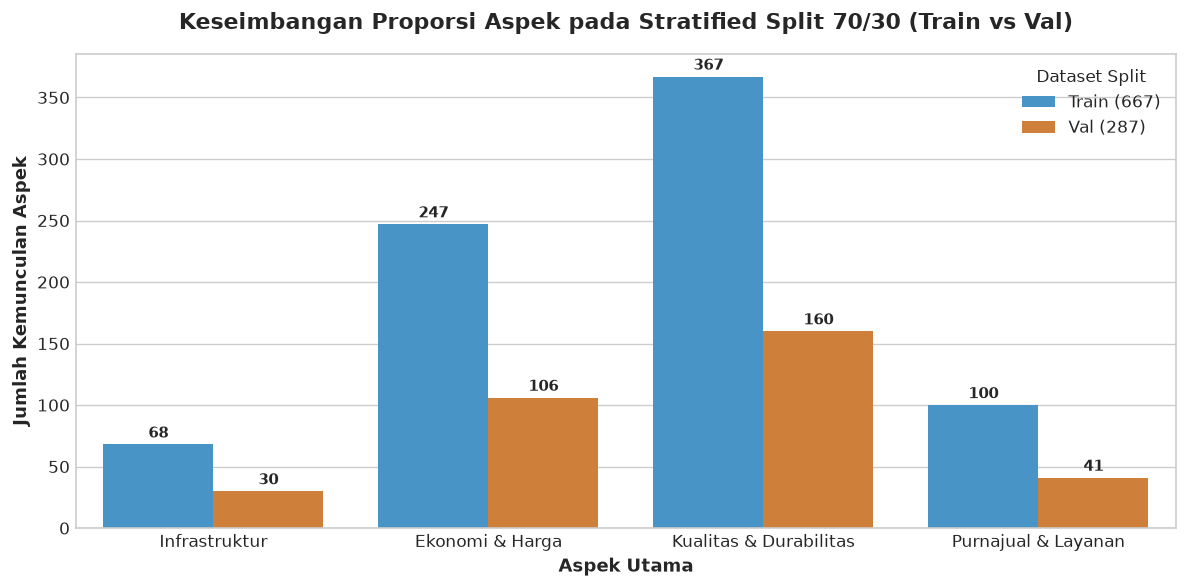

In [9]:
# 6. Verifikasi Keseimbangan Distribusi Aspek & Sentimen pada Stratified Split 70/30 (Train vs Val)
def get_split_aspect_counts(df, split_name):
    row = {'Split': split_name}
    for col, name in aspect_names.items():
        row[name] = df[col].notnull().sum()
    return row

split_summary = pd.DataFrame([
    get_split_aspect_counts(df_train, f'Train ({len(df_train)})'),
    get_split_aspect_counts(df_val, f'Val ({len(df_val)})')
])

print("Tabel Kemunculan Aspek pada Stratified Dataset Split (70/30):")
print(split_summary.to_string(index=False))

# Detail Distribusi Sentimen per Aspek pada Split 70/30
print("\nDetail Distribusi Sentimen per Split (Train 70% vs Val 30%):")
for a_col, a_name in aspect_names.items():
    print(f"\n[Aspek {a_name}]")
    df_s = pd.DataFrame({
        'Train (70%)': df_train[a_col].value_counts(dropna=False),
        'Val (30%)': df_val[a_col].value_counts(dropna=False)
    }).fillna(0).astype(int)
    print(df_s)

# Visualization Plot Bar Split
split_melted = pd.melt(split_summary, id_vars=['Split'], var_name='Aspek', value_name='Jumlah')

plt.figure(figsize=(10, 5))
sns.barplot(data=split_melted, x='Aspek', y='Jumlah', hue='Split', palette=['#3498db', '#e67e22'])
plt.title('Keseimbangan Proporsi Aspek pada Stratified Split 70/30 (Train vs Val)', fontsize=13, fontweight='bold', pad=15)
plt.ylabel('Jumlah Kemunculan Aspek', fontsize=11, fontweight='bold')
plt.xlabel('Aspek Utama', fontsize=11, fontweight='bold')
plt.legend(title='Dataset Split')

for p in plt.gca().patches:
    h = p.get_height()
    if h > 0:
        plt.gca().annotate(f'{int(h)}', (p.get_x() + p.get_width() / 2., h),
                           ha='center', va='bottom', fontsize=9, fontweight='bold', xytext=(0, 2), textcoords='offset points')

plt.tight_layout()
plt.show()


## 📌 Kesimpulan & Temuan Kunci EDA Dataset 100% Pure Human Gold Standard

1. **Rasio Data Ber-Aspek Murni Manusia:** Dari total **3.016 komentar**, sebanyak **954 komentar (31,6%)** merupakan komentar valid ber-aspek murni hasil audit manusia (*Pure Human Gold Standard*). Seluruh label mesin yang tidak diaudit telah dieliminasi secara total.
2. **Akumulasi Distribusi Sentimen Keseluruhan:**
   - Total terdapat **1.119 anotasi label sentimen** murni buatan manusia.
   - **Netral  :** 451 label (40,3%)
   - **Positif :** 441 label (39,4%)
   - **Negatif :** 227 label (20,3%)
   - *Keseimbangan Sentimen:* Distribusi sentimen manusia terbukti sangat berkualitas (40,3% Netral, 39,4% Positif, 20,3% Negatif).
3. **Dominasi Aspek:** 
   - **Kualitas & Durabilitas** adalah aspek yang paling banyak didiskusikan (630 komentar), disusul **Ekonomi & Harga** (479 komentar).
   - **Purnajual** (172 komentar) dan **Infrastruktur** (123 komentar) merupakan aspek minoritas.
4. **Validasi Stratified Split 70/30 (Train vs Val):** 
   - Dataset latih `train.csv` (**667 data**) dan validasi `val.csv` (**287 data**) terbagi secara **Stratified Multi-Aspect 70:30** tanpa data leakage.
5. **Kesiapan Phase 3:** Dataset `train.csv` (667) dan `val.csv` (287) **siap 100%** untuk tahap pelatihan model diskriminatif (**IndoRoBERTa Classifier** vs **SahabatAI-8B Classifier** di Kaggle Notebook).
